# Probability and Random Variables
We have now established that *variance* is the key property that we wish to capture from any given dataset. The fact that measured values differ from datapoint-to-datapoint implies an inherent *randomess* and *uncertainty* to real-world data. As such, in order to say anything about the variance in our data, we need some means of formalising this randomness. This formalisation comes from the world of *probability*. 


`````{admonition} The Meaning of "Randomness"
:class: tip
Unlike the common understanding of the term, *randomness* in probability does not mean completely unstructured and unpredictable. In everyday speech, when we say that something happened "randomly", that is often taken as meaning that it could not have been predicted. However, in the more formal world of probability, the term *random* has a very specific definition that means something that is unpredictable in the short term, but has a *predictable regularity* over the long term. This is captured within the concept of a *random variable*.
`````

## Random Variables
A *random variable* refers to any variable whose value changes with each measurement, but whose behaviour over time adheres to a known *probability distribution*. This is an important concept because every value that we measure as part of an experiment is conceptualised as a realisation of a given random variable. For instance, we would treat *reaction time* as a random variable, with each measured value of reaction time representing a realistion of that random variable. Implicit in this is the idea that reaction time adheres to some probability distribution and that our experiment is simply the process of sampling value from that distribution.

In general, there are two different classes of random variable: *discrete* and *continuous*. This is an important distinction because one of the first things we need to do when analysing a dataset is determine which of the outcome variables are *discrete* and which are *continuous*. This will then dictate the range of models that are possible. 

### Discrete Random Variables
The first class of random variables concern those where the number of possible outcomes is *finite*. For instance, tossing a coin and seeing whether the outcome is either heads or tails. Counting the face values of two dice would also be discrete, because there are only a limited number of outcomes. Indeed, counting anything would be considered discrete because there are only a finite number of possibilities, with no values in-between. In all these cases, we can consider the outcome of the experiment[^probexp] to be a random variable governed by some discrete probability distribution.

The textbook example of this is counting the number of heads after flipping a coin multiple times. For instance, if we flipped a coin 20 times then the probability of different numbers of *heads* can be described by the *binomial* distribution. If $y$ is the count of the number of *heads*, then $y$ is a random variable drawn from the binomial distribution, which we write as

$$
y \sim \mathcal{B}\left(n,p\right).
$$

The shape of the distribition is controlled by two *parameters*, $n$ and $p$. In this example, $n$ is the number of coin flips and $p$ is the probability of *heads* on a single flip. So, here $n = 20$ and (assuming the coin is fair) $p = 0.5$. Knowing these parameter values allows us to know everything we need to about the behaviour of $y$. 

`````{admonition} What is a Parameter?
:class: tip
A *parameter* is simply a number, but one which has a particular *importance* for understanding some system. In the context of probability distributions, the parameters are numbers that control the *shape* of the distribution. We typically conceptualise a probability distribution as representing some *population*, where the parameters are constants that describe the behaviour of that population. As such, the parameters carry great importance for understanding the variable we are measuring. The primary aim of any parametric statistical analysis is to estimate the parameters of the population distribution. Once these values are known, we known everything we need to about the variable in question.
`````



We can use `R` to simulate realisations of this random variable 

In [1]:
set.seed(666)
y <- rbinom(n=10, size=20, prob=0.5)
y

[1] 12  8 14  8  9 11 14 10  5  9

which we can think of 10 repeats of flipping a coin 20 times and counting the number of heads. The first time we do this, we get $\frac{12}{20}$ heads, the second time we get $\frac{8}{20}$ heads and so on. Notice that we have no real way of knowing what the next value will be and thus, in the short-term, the variable $y$ is unpredictable. However, in the long-term, we know how frequently certain values will appear and thus there is a much more general sense of predictability. 

We can visualise the complete distribution $\mathcal{B}\left(20,0.5\right)$ using the code below. You can play around with the values of `n` and `p` to see how the distribution changes shape.

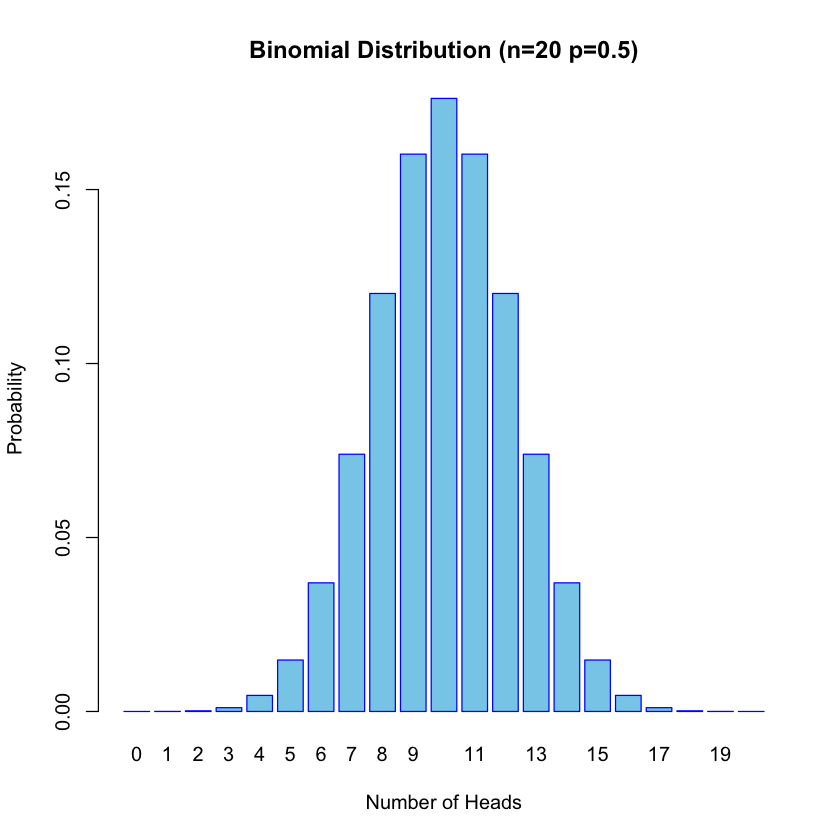

In [2]:
# Binomial probabilities
n <- 20
p <- 0.5
y <- dbinom(0:n, size=n, prob=p)

# Plot
barplot(y, names.arg=0:n, 
        main=paste0("Binomial Distribution (n=", n, " p=", p, ")"), 
        xlab="Number of Heads", ylab="Probability", col="skyblue", 
        border="blue")

Although experimental psychologists do not spend much time flipping coins, we need to think more generally about the utility of probability distributions. For instance, imagine an experiment where each subject completes a number of trials. After each trial, their response can be categorised in one of two ways. Over all the trials we sum the number of times their response is in one category rather than the other. In this example, the measurement could be considered a binomial random variable, with $n$ equal to the number of trials and $p$ unknown. The purpose of the experiment is then to estimate what $p$ might be and, potentially, how $p$ changes under different manipulations.

Other examples of discrete probability distributions include the [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution), [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution) and the [negative binomial distribution](https://en.wikipedia.org/wiki/Negative_binomial_distribution).

`````{admonition} Treating Discrete as Continuous
:class: important
In many real-world cases of discrete random variables, you may find them being treated as *continuous* for the purpose of statistical analysis. For instance, the binomial distribution shown above *could* be approximated by a normal distribution. Historically, psychologists do this frequently when dealing with discrete data, such as the scores from a questionnaire or counts of the number of items remembered after a memory test. An argument can be made that the underlying structure that we are measuring is continuous and thus a predicted questionnaire score of `5.324` or quoting `7.235` items remembered are meaningful representation of the *latent variable* that is being captured. However, in many cases, this is done simply because psychologists are not well-trained on how to deal with discrete outcomes and so often simply ignore the true nature of what they are measuring. To become a powerful researcher in experimental psychology, it is important that this sort of information is *not* ignored and that the data are treated appropriately.
`````

### Continuous Random Variables
The second class of random variables concern those where the number of possible values is *infinte*. This can either be within an *unbounded* range (so the values can span $-\infty$ to $\infty$), or within a *bounded* range (such as anything between 0 and 1).

In many real-world situations our measurements are continuous and so treating the outcomes of experiments as *continuous* random variables is common. Indeed, huge amount of statistical theory are exclusively dedicated to continuous random variables. As an example, measuring the *height* of females in the UK could be conceptualised as a random variable drawn from a *normal* distribution. If $y$ is the measurement of *height*, we would write

$$
y \sim \mathcal{N}\left(\mu,\sigma^{2}\right).
$$

Like the binomial distribution, the shape of the normal distribution is controlled by two parameters. The first is the *mean* (denoted $\mu$), which controls the value that the distribution is centred-on. The second is the *variance* (denoted $\sigma^{2}$), which controls the *width* of the distribution and thus how much values drawn from the distribution will differ from the mean. 

For the example of *height*, we could set $\mu = 162$ and $\sigma^{2} = 6^{2} = 36$, both measured in centimetres. We could then use `R` to simulate realisations of this random variable using the `rnorm` function[^rnorm]

In [3]:
y <- rnorm(n=10, mean=162, sd=sqrt(36))
y

[1] 166.5504 154.1629 157.1849 151.2466 161.7478 174.9003 151.3786 167.1879
 [9] 151.6791 162.8048

which we can think of as measuring the height of 10 random females in the UK. We can also visualise the distribution $\mathcal{N}\left(162,36\right)$ using the code below. Again, you can play around with the values of `mean` and `sd` to see how the distribution changes shape.

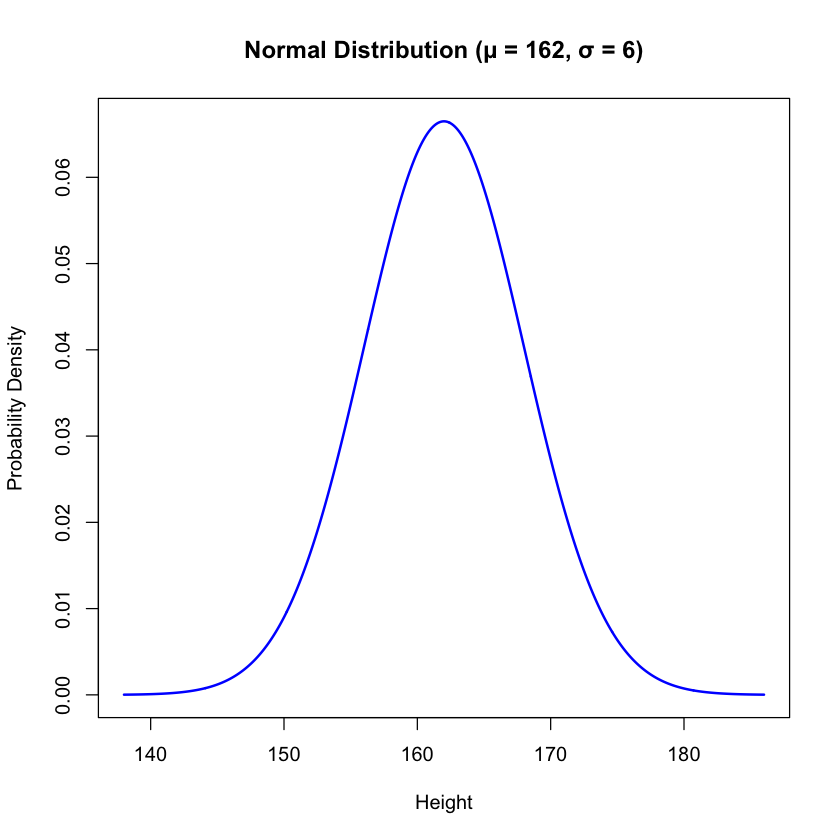

In [4]:
# Normal parameters
mean <- 162
sd   <- sqrt(36)

# Generate x values (+/- 4 SDs from the mean)
x <- seq(mean-4*sd, mean+4*sd, length=1000)

# Calculate the normal density
y <- dnorm(x, mean=mean, sd=sd)

# Plot
plot(x, y, type = "l", lwd = 2, col = "blue",
     main = paste0("Normal Distribution (μ = ", mean, ", σ = ", sd, ")"),
     xlab = "Height", ylab = "Probability Density")

Like the example earlier, it is unlikely that, as an experimental psychologist, you would spend much time measuring people's *height*. However, thinking more generally, you might end up measuring *reaction time*, scores from a *visual analogue scale*, *IQ*, metrics derived from *eye-tracking* or *time spent* attending to a visual stimulus. These are all examples of measures that can, in theory, take an infinite number of values within a given range and thus are all examples of continuous random variables. 

Although the normal distribution is used most frequently, other examples of continuous probability distributions include the [gamma distribution](https://en.wikipedia.org/wiki/Gamma_distribution), [log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution) and the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution).

`````{admonition} The Core Assumptions of an Experiment
:class: tip
When we conduct an experiment, we concptualise the variables that we are measuring as *random variables*. This means that their values will change with each measurement and are governed by some random process. In this context, *random* means that their behaviour adheres to some probability distribution. As such, the variance in our measurements contains a known structure in terms of the underlying probability distribution. Our experiment is then conceptualised as the process of making random draws from that distribution. The shape of the distribution is governed by a number of *parameters*, which are conceptualised as *fixed constants* of the population we are drawing samples from. Our aim, very generally, is to use the information in the sample to estimate those population parameter values. This is how a statistical model attempts to explain the seemingly random variations in real-world measurements.
`````

## The Expected Value of a Distribution
All distributions have a property known as the *expected value*. Informally, this is equivalent to the *mean* of the distribution and thus it tells us the value that we *expect*, on average. More formally, the expected value is a form of *weighted-average*, where each value is weighted by its probability. However, the precise mathematical definition is not really important for our purposes. Instead, we just need to understand the term conceptually. For instance, if we have a random variable $y$ that adheres to

$$
y \sim \mathcal{N}\left(\mu,\sigma^{2}\right),
$$

then the mathematical definition of the expected value results in

$$
E\left(y\right) = \mu.
$$



As such, our *expectation* for any realisation of $y$ would be equal to the mean of the distribution. This is an obvious example because the normal distribution has an expected value that is equal to one of its parameters. However, the principle is applicable to *any* distribution, whether its mean is coded directly by one of the parameters or not. For instance, if we had

$$
y \sim \mathcal{B}\left(n,p\right)
$$

then the expected value of $y$ turns out to be

$$
E\left(y\right) = np.
$$

You can verify this by looking at the distribution we visualised earlier. 

## The Variance of a Distribution
As well as an expected value, all distributions have some concept of *variance*. Informally, this captures the *width* of the distribution and thus dictates the degree to which we expect our measurements to deviate from the expected value, on average. This tells us how *consistent* the data are with the expected value. Much like the expected value, the variance of a specific distribution is captured using some function of the parameters. In the case of the normal distribution we have 

$$
y \sim \mathcal{N}\left(\mu,\sigma^{2}\right),
$$

and the variance is simply

$$
\text{Var}\left(y\right) = \sigma^{2}.
$$

Again, this is fairly obvious. If instead we have 

$$
y \sim \mathcal{B}\left(n,p\right)
$$

then the variance of $y$ turns out to be

$$
\text{Var}\left(y\right) = np\left(1-p\right),
$$

which is much less obvious. Whether the variance is clearly coded in the parameters of the distribution or not, the important point is that *all* distributions contain some metric of variance.

`````{admonition} Equations for the Expected Value and Variance
:class: tip
If you are ever curious, the [Wikipedia pages](https://en.wikipedia.org/wiki/Probability_distribution) for all the most common probability distributions contain tables giving the formulas for their various properties, including the mean and variance. For some distributions, the mean and variance are more obviously coded within their parameters (e.g. the normal distribution, the Poisson distribution), whereas for others these properties are more complex functions of the parameters (e.g. the binomial distribution, the uniform distribution).
`````

## Why are the Expected Value and Variance Important?
At the beginning of this lesson, we discussed the concept of variance as an informal description of what we could see when we plotted some data. Although useful, this could not be used to *explain* or *predict* the data, it just quantified what we already knew. In order to explain and predict the data, we need some mathematical description of the *data-generating process*. This is precisely what a probability distribution does. Furthermore, the properties of the *expected value* and the *variance* allow us to partion the data-generating process into those elements that are *predictable* and those elements that are *unpredictable*.

With this in mind, the expected value captures the element of the data-generating process that is *predictable*. The expected value is not subject to random variation, meaning that it is the element of the distribution that *does not change* across measurements. The expected value can therefore be thought of as representing some *universal truth* of the variable in question. Because of this, we can conceptualise any realisation of a random variable as the expected value plus some random variation

$$
y_{i} = E\left(y\right) + \epsilon_{i}.
$$

Here, $\epsilon_{i}$ is the $i$th *error*, conceptualised as the difference between the value we expected and the actual value of $y_{i}$. In other words

$$
\epsilon_{i} = y_{i} - E\left(y\right).
$$

`````{admonition} Understanding Indices
:class: tip
In the equation above we used $y_{i}$ to indicate a non-specific instance of the random variable $y$. The little $i$ is known as an *index*. It is a short-hand way of expressing "any value of $y$". Typically, the range of the index would be indicated using an expression such as $i = 1, \dots, n$, which just tells us that $i$ can take any value between 1 and $n$, where $n$ is the total number of datapoints. It is effectively a short way of writing

$$
\begin{align*}
y_{1} &= E\left(y\right) + \epsilon_{1} \\
y_{2} &= E\left(y\right) + \epsilon_{2} \\
y_{3} &= E\left(y\right) + \epsilon_{3} \\
\vdots                     \\
y_{n} &= E\left(y\right) + \epsilon_{n}. \\
\end{align*}
$$

As we can see, whenever we use an index we are actually inferring that there are *multiple* equations across the range of the index. The important thing to note is that terms with an index will change across the equations, whereas terms *without* an index remain constant. Because of this, we can already infer from the expression

$$
y_{i} = E\left(y\right) + \epsilon_{i}
$$

that $E\left(y\right)$ is the same across all the equations, whereas $y_{i}$ and $\epsilon_{i}$ can change.

A connection can be made here with programming in `R`, as this is much the same as typing `y[1]` or `y[2]`, where the value in brackets is the *index* of the variable `y`. We can think of $y_{i}$ as akin to using `y[i]` in a loop, where the variable `i` could refer to any index from 1 through to $n$. As such, we can think of the mathematical expression above as being akin to the code

	
```R
for (i in 1:n){
    y[i] = mean(y) + error[i]
}
```

which we know is short for

```R
y[1] = mean(y) + error[1]
y[2] = mean(y) + error[2]
y[3] = mean(y) + error[3]
y[4] = mean(y) + error[4]
...
```

`````

To understand this notion of the expected values and the errors more clearly, take the random variable

$$
y_{i} \sim \mathcal{N}\left(\mu,\sigma^{2}\right)
$$

with $\mu = 2$ and $\sigma^{2} = 1$. Imagine that the first value we sampled $(i=1)$ was equal to 5. Because $E(y) = \mu$, we can think of this as being the mean plus some random variation

$$
\begin{align*}
y_{1} &= \mu + \epsilon_{1} \\
      &= 2 + 3 \\ 
      &= 5.
\end{align*}
$$

Imagine that the second value we sampled $(i=2)$ was then equal to 0.5. We can think of this as

$$
\begin{align*}
y_{2} &= \mu + \epsilon_{2} \\ 
      &= 2 + -1.5           \\
      &= 0.5.
\end{align*}
$$

So notice that there is an element that is *constant* across measurements and an element that *changes* with each measurement. In this way, every single value we measure *contains* the expected value of the distribution, but has been deflected from the expected value by some random perturbation. 

Going back to the idea of capturing the *predictable* and *unpredictable* elements of a variable, it is the *variance* of the distribution that captures this unpredictability. As we have seen, the expected value is not subject to random variation and thus it is considered *constant* across measurements. Because of this, the expected value cannot be the source of the random variation that we see in real data. As such, the randomness must come from the errors. As we saw above, each measurement we make is associated with the *same* expected value and a *different* error. It is therefore $\epsilon$ that has probabilistic behaviour. This means that we can express the probability model

$$
y_{i} \sim \mathcal{N}\left(\mu,\sigma^{2}\right)
$$

as

$$
\begin{align*}
y_{i} &= \mu + \epsilon_{i} \\
\epsilon_{i} &\sim \mathcal{N}\left(0,\sigma^{2}\right)
\end{align*}
$$

Thus, the random behaviour of $y$ can be split into a non-random part ($\mu$) and a random part ($\epsilon$). Because it is considered a random variable, this means that $\epsilon$ has a probability distribution identical to $y$, but with a change of expectation. 

We can illustrate this in `R` by removing the expected value from the data and visualising the distribution. When we do this, all that happens is that we centre the data around 0. Importantly, we do not remove any of the randomness. Using `mpg` as an example, we have

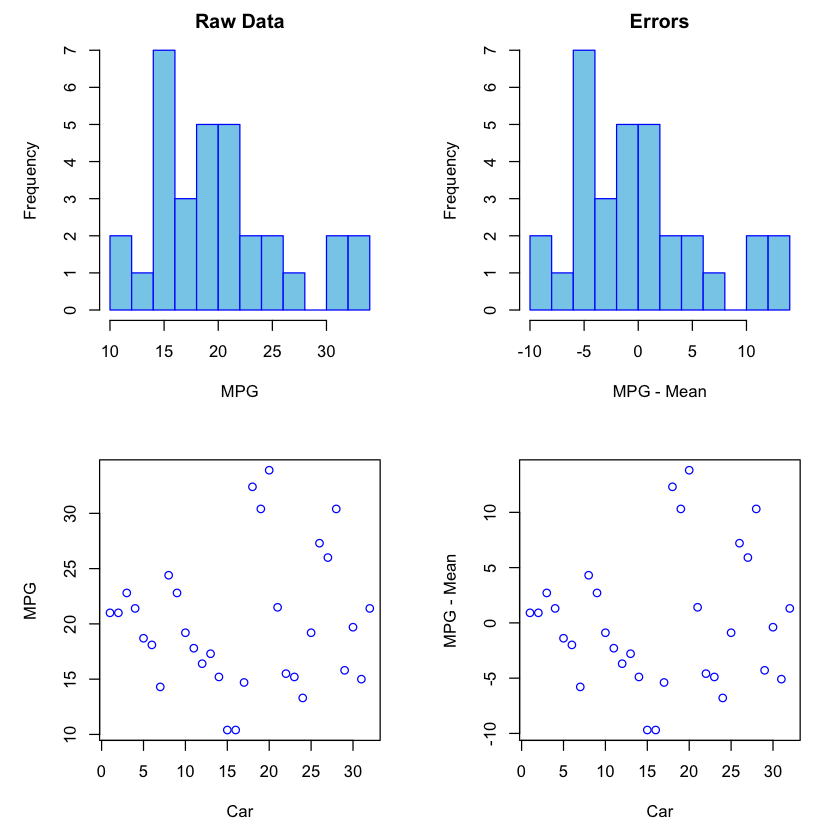

In [5]:
par(mfrow=c(2,2), mar=c(5,5,2,2))

mpg <- mtcars$mpg
err <- mtcars$mpg - mean(mtcars$mpg)
n   <- length(mpg)

hist(mpg, breaks=10, xlab="MPG",        main="Raw Data", col="skyblue", border="blue")
hist(err, breaks=10, xlab="MPG - Mean", main="Errors",   col="skyblue", border="blue")

plot(mpg, xlab="Car", ylab="MPG",        main="", col="blue")
plot(err, xlab="Car", ylab="MPG - Mean", main="", col="blue")

So notice that both the *errors* and the *raw data* have *the same form of distribution*. The only element that changes is that the mean of the error distribution is 0. We will see the importance of this as we progress on this unit, as many elements of statistical modelling concern themseleves with the behaviour of the *errors* and not the raw data.

From the plots above, we can see that the errors indicate the degree to which the data deviate from their expectation. Any error with a magnitude of 0 does not deviate from the expectation, whereas an error with a magnitude of 10 (for example) indicates that a particular datapoint was 10 units away from where we expected it to be. The errors therefore capture the *variance* of the random variable in question. As such, the total variation in $y$ can be broken into two sources. The first is the expected value, which is *constant* across all the values, and the second is the *error*, which indicates the degree to which the data deviates from the expected value. The expected value influences how *predictable* the data are and the errors influence how *unpredictable* the data are. This is the *centre* and the *width* of the assumed probability distribution that generated the data.

This can all be made clearer by considering the *actual* formal definition of variance:

$$
\text{Var}\left(y\right) = E\left[\left(y - E\left[y\right]\right)^{2}\right]
$$

As we know, subtracting the expected value from the data gives us the *errors*, meaning we can rewrite the variance as

$$
\text{Var}\left(y\right) = E\left(\epsilon^{2}\right).
$$

So the variance is really the expected value of the squared errors. In other word, the *mean* of the squared errors. This fits precisely with our concept of variance from earlier. The difference now is that this metric is defined in reference to the assumed distribution of the data. Rather than just being a simple description of what we could see when we plotted the data, we now have a *mathematical model of the data-generating process*. Depending upon the accuracy of this model, we can now say where that data came from and can also make prediction about what values it may have in the future.

```{admonition} Advanced: The Expected Value of the Squared Errors
:class: warning, dropdown
In order to fully derive the expression for the variance above, we need to know the distribution of the squared-errors, in order to understand its expected value. A key point to understand is that manipulating a random variable does not remove the randomness, it just changes it. As such, we manipulate $y$ to produce $\epsilon$, which changes the distribution. We manipulate $\epsilon$ again to produce $\epsilon^{2}$, which changes the distribution. Statistical theory tells us that this will be a *scaled* version of the Chi-square distribution, which has the form 

$$
y \sim c \cdot \chi^{2}\left(k\right).
$$

In this instance, $c = \sigma^{2}$ and $k = 1$, giving

$$
\epsilon^{2} \sim \sigma^{2} \cdot \chi^{2}\left(1\right).
$$

The expected value of a scaled Chi-square is simply $ck$, meaning that

$$
E\left(\epsilon^{2}\right) = ck = \sigma^{2}.
$$

Applying the formal mathematical definition of the expected value further simplifies this to simply taking the *average* of the squared-errors. As such, the variance of $y$ is equivalent to the average of the squared-errors. This why the variance is sometimes referred to as the *mean squared error* (MSE).
```

`````{topic} What do you now know?
In this section, we have explored the important concept of *random variables*, *probability distributions*, and the most useful properties of those distributions. After reading this section, you should have a good sense of:

- What a *random variable* is, particularly in terms of the difference between *discrete* and *continuous* random variables.
- The notation used to express a random variable in relation to its distribution, such as $y \sim \mathcal{B}(n,p)$.
- What a *parameter* is in relation to a probability distribution and why it is important.
- What the *expected value* of a distribution is, the notation for expressing the expected value and why it is important.
- What the *variance* of a distribution is, the notation for expressing the variance and why it is important.
- How indices are used in notation to denote different values.
- The concept of splitting every measured value in its expectation and error, with the errors having the same distributional form as the raw data, but with a mean of 0.
`````

[^probexp]: Note that an "experiment" in the context of probability theory has a much broader definition than we would typically use in science.

[^rnorm]: Note that the `rnorm` function parameterises the normal distribution using the *standard deviation*, rather than the *variance.*